In [2]:
import mysql.connector as sql
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
customer_df = pd.read_csv("customers.csv")
customer_df

,CustomerID,Name,Age,Gender,Region,IncomeLevel
0,1,Sneha Sharma,39,Male,South,Low
1,2,Sneha Iyer,56,Male,Central,Medium
2,3,Priya Sharma,27,Male,South,High
3,4,Leela Sharma,57,Male,Central,Medium
4,5,Anjali Mehta,59,Female,North,Low
...,...,...,...,...,...,...
145,146,Kiran Choudhury,50,Female,Central,Medium
146,147,Kavya Nair,61,Male,Central,High
147,148,Sneha Rao,35,Male,East,High
148,149,Rahul Singh,37,Male,Central,Low


In [4]:

account_df = pd.read_csv("accounts.csv")
account_df

,AccountID,Cust_id,AccountType,Balance,AccountStatus
0,1,75,Savings,119580.74,Closed
1,2,117,Savings,345255.54,Dormant
2,3,51,Fixed Deposit,61814.27,Active
3,4,39,Loan,414182.42,Active
4,5,43,Loan,299546.80,Closed
...,...,...,...,...,...
245,246,75,Fixed Deposit,432761.11,Active
246,247,41,Loan,467207.01,Closed
247,248,49,Current,251641.44,Active
248,249,128,Loan,251198.29,Active


In [5]:
transaction_df = pd.read_csv("transactions.csv")
transaction_df

,TransactionID,Acc_ID,Date,Amount,TransactionType
0,1,91,2023-01-25,2621.97,Debit
1,2,153,2023-12-01,33658.78,Debit
2,3,138,2023-01-05,42373.90,Debit
3,4,35,2023-05-16,36402.65,Debit
4,5,94,2023-01-24,20089.02,Credit
...,...,...,...,...,...
4995,4996,148,2023-07-12,29662.01,Credit
4996,4997,152,2023-06-14,22597.88,Debit
4997,4998,92,2023-04-05,3103.89,Credit
4998,4999,208,2023-03-12,1006.19,Credit


In [6]:
# Database Connection
conn = sql.connect(
    host="localhost",
    user="root",
    password="situn359k",
    database="BI"
)
mycursor = conn.cursor()

# SQL Queries
customers = "SELECT * FROM Customers"
accounts = "SELECT * FROM Accounts"
transactions = "SELECT * FROM Transactions"

In [7]:
# Load data from MySQL into pandas DataFrames
mycursor.execute(customers)
customer_fetch = mycursor.fetchall()
customer_columns = [col[0] for col in mycursor.description]
customer_df = pd.DataFrame(customer_fetch, columns=customer_columns)

mycursor.execute(accounts)
account_fetch = mycursor.fetchall()
account_columns = [col[0] for col in mycursor.description]
account_df = pd.DataFrame(account_fetch, columns=account_columns)

mycursor.execute(transactions)
transaction_fetch = mycursor.fetchall()
transaction_columns = [col[0] for col in mycursor.description]
transaction_df = pd.DataFrame(transaction_fetch, columns=transaction_columns)

In [8]:
# Display basic dataset information
print(customer_df.head())
print(account_df.head())
print(transaction_df.head())

print("\n----- DATA INFO -----")
print(customer_df.info())
print(account_df.info())
print(transaction_df.info())

print("\n----- DESCRIBE -----")
print(customer_df.describe())
print(account_df.describe())
print(transaction_df.describe())

   CustomerID          Name  Age  Gender   Region IncomeLevel
0           1  Sneha Sharma   39    Male    South         Low
1           2    Sneha Iyer   56    Male  Central      Medium
2           3  Priya Sharma   27    Male    South        High
3           4  Leela Sharma   57    Male  Central      Medium
4           5  Anjali Mehta   59  Female    North         Low
   AccountID  Cust_id    AccountType    Balance AccountStatus
0          1       75        Savings  119580.74        Closed
1          2      117        Savings  345255.54       Dormant
2          3       51  Fixed Deposit   61814.27        Active
3          4       39           Loan  414182.42        Active
4          5       43           Loan  299546.80        Closed
   TransactionID  Acc_ID        Date    Amount TransactionType
0              1      91  2023-01-25   2621.97           Debit
1              2     153  2023-12-01  33658.78           Debit
2              3     138  2023-01-05  42373.90           Debit
3   

In [9]:
# Data cleaning and preprocessing
customer_df.drop_duplicates(inplace=True)
account_df.drop_duplicates(inplace=True)
transaction_df.drop_duplicates(inplace=True)

customer_df.dropna(inplace=True)
account_df.dropna(inplace=True)
transaction_df.dropna(inplace=True)


In [10]:
transaction_df["Date"] = pd.to_datetime(transaction_df["Date"])

In [11]:
# KPI analysis
print("Total Customers:", len(customer_df))

closed_accounts = account_df[account_df["AccountStatus"] == "Closed"].shape[0]
print("Closed Accounts:", closed_accounts)

loan_accounts = account_df[account_df["AccountType"] == "Loan"].shape[0]
print("Loan Accounts:", loan_accounts)



Total Customers: 150
Closed Accounts: 47
Loan Accounts: 70


In [12]:
# Convert Balance to numeric
account_df["Balance"] = pd.to_numeric(account_df["Balance"], errors="coerce")

# Merge Customers and Accounts
merged = pd.merge(
    customer_df,
    account_df,
    left_on="CustomerID",
    right_on="Cust_id",
    how="inner"
)

print(merged.shape)
print(merged.head())

(250, 11)
   CustomerID          Name  Age  Gender Region IncomeLevel  AccountID  \
0           1  Sneha Sharma   39    Male  South         Low         31   
1           3  Priya Sharma   27    Male  South        High         52   
2           5  Anjali Mehta   59  Female  North         Low        180   
3           6   Meena Gupta   39    Male  South      Medium         84   
4           7   Sneha Patel   46    Male   East      Medium         89   

   Cust_id    AccountType    Balance AccountStatus  
0        1           Loan  364395.24        Closed  
1        3  Fixed Deposit  451098.66        Active  
2        5           Loan  111749.10        Active  
3        6        Savings  394463.32        Active  
4        7        Current   12355.86        Closed  


In [13]:
# Region Wise Balance
region_balance = pd.merge(
    customer_df,
    account_df,
    left_on="CustomerID",
    right_on="Cust_id",
    how="inner"
)
region_balance = region_balance.groupby("Region")["Balance"].sum()

print("\nRegion Wise Balance")
print(region_balance)



Region Wise Balance
Region
Central     9056949.61
East       10604689.77
North      15851540.23
South      12029947.95
West       18123939.28
Name: Balance, dtype: float64


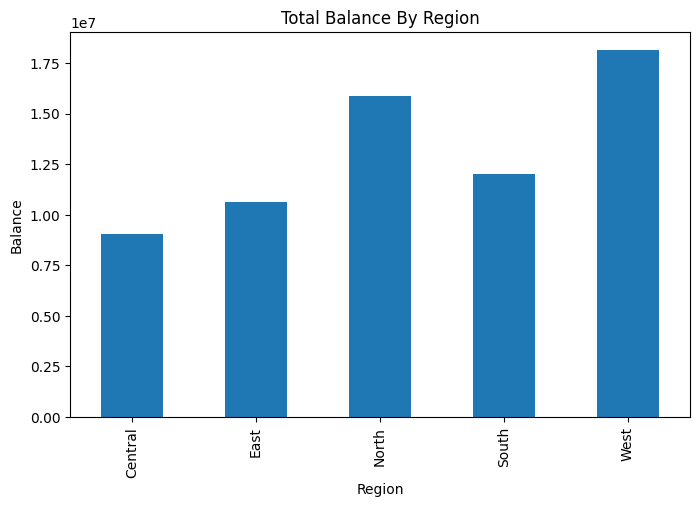

In [14]:
# Visualizations

# Chart 1
plt.figure(figsize=(8,5))
region_balance.plot(kind="bar")
plt.title("Total Balance By Region")
plt.xlabel("Region")
plt.ylabel("Balance")
plt.show()

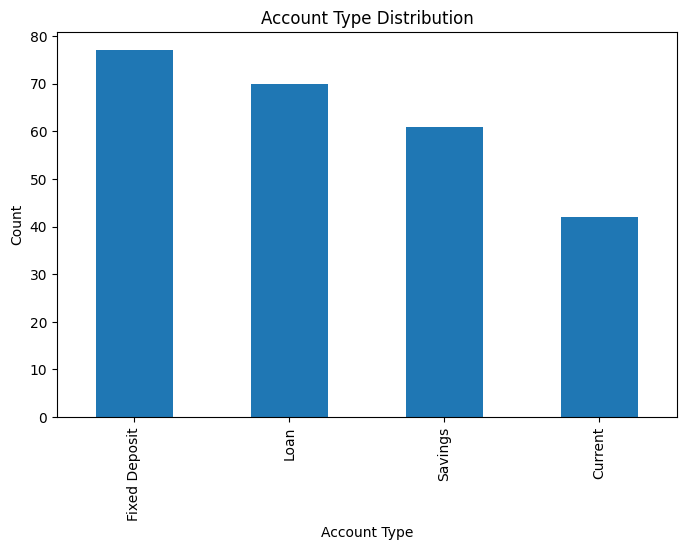

In [15]:
# Account Type Distribution
account_type = account_df["AccountType"].value_counts()

plt.figure(figsize=(8,5))
account_type.plot(kind="bar")
plt.title("Account Type Distribution")
plt.xlabel("Account Type")
plt.ylabel("Count")
plt.show()

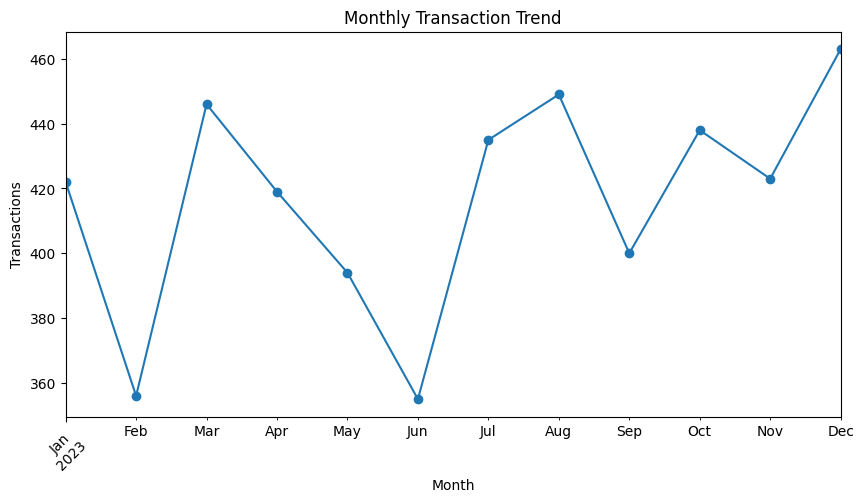

In [16]:
transaction_df["Month"] = transaction_df["Date"].dt.to_period("M")
monthly_txn = transaction_df.groupby("Month").size()
plt.figure(figsize=(10, 5))
monthly_txn.plot(marker="o")
plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.show()

In [17]:
conn.close()